## Access Satellite Wind Altimeter Delayed Qc (Zarr)
This Jupyter notebook demonstrates how to access and plot satellite_wind_altimeter_delayed_qc data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/b02b929f-2caf-45d4-ac60-d4632b7ca0ca).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/satellite_wind_altimeter_delayed_qc.ipynb).


In [1]:
dataset_name = "satellite_wind_altimeter_delayed_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 201 packages in 49ms
Checked 201 packages in 0.99ms


✅ Virtual environment already exists, skipping creation.
✅ Local version 0.3.17 is up to date (remote: 0.3.16)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4603: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 1.64 s, sys: 1.1 s, total: 2.74 s
Wall time: 2.34 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	LATITUDE = 5000 ;
	LONGITUDE = 8500 ;
	TIME = 2868 ;

variables:
	float32 LATITUDE(LATITUDE) ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float32 LONGITUDE(LONGITUDE) ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LONGITUDE:standard_name = longitude ;
		LONGITUDE:units = degrees_east ;
		LONGITUDE:valid_max = 360.0 ;
		LONGITUDE:valid_min = 0.0 ;
	datetime64[ns] TIME(TIME) ;
		TIME:axis = T ;
		TIME:long_name = time ;
		TIME:standard_name = time ;
		TIME:valid_max = 90000 ;
		TIME:valid_min = 0 ;
	datetime64[ns] TIME_AT(TIME, LATITUDE, LONGITUDE) ;
		TIME_AT:long_name = Time at each along-track observation ;
		TIME_AT:standard_name = time ;
		TIME_A

In [6]:
ds

<xarray.Dataset> Size: 6TB
Dimensions:                   (LATITUDE: 5000, LONGITUDE: 8500, TIME: 2868)
Coordinates:
  * LATITUDE                  (LATITUDE) float32 20kB -48.99 -48.99 ... 0.995
  * LONGITUDE                 (LONGITUDE) float32 34kB 95.0 95.01 ... 180.0
  * TIME                      (TIME) datetime64[ns] 23kB 2017-10-24 ... 2025-...
Data variables:
    TIME_AT                   (TIME, LATITUDE, LONGITUDE) datetime64[ns] 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WDIR                      (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WSPD                      (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WSPD_CAL                  (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WSPD_CAL_quality_control  (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WSPD_quality_control      (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    filename                  (TIME) object 23kB dask.array<chunksize=(40,), meta=np.ndarray>
Attributes: (12/32)
    Conventions:                   CF-1.6,IMOS-1.4
    abstract:                      This dataset contains regularly gridded (0...
    acknowledgement:               Any users of IMOS data are required to cle...
    author:                        Khan, Salman Saeed
    author_email:                  salmansaeed.khan@csiro.au
    cdm_data_type:                 Grid
    ...                            ...
    project:                       Integrated Marine Observing System (IMOS)
    source:                        Sentinel-1 level-2 ocean wind (owi) produc...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    time_coverage_end:             2025-08-30T22:27:11Z
    time_coverage_start:           2025-08-30T06:39:22Z
    title:                         Daily Sentinel-1 SAR ocean surface winds r...

## Plot time coverage

In [7]:
aodn_dataset.get_temporal_extent()

(Timestamp('2017-10-24 00:00:00'), Timestamp('2025-08-31 00:00:00'))

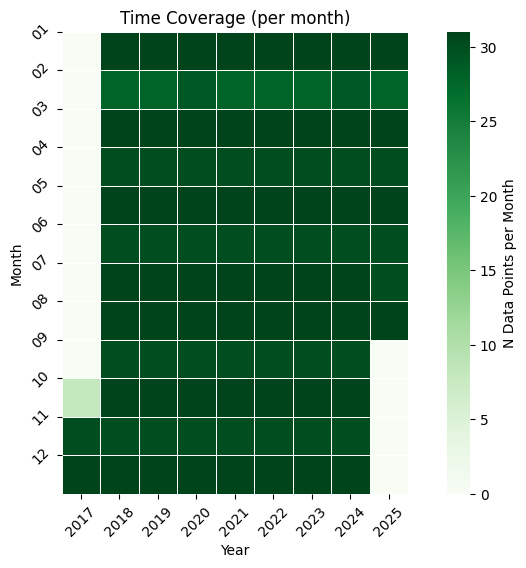

In [8]:
aodn_dataset.plot_time_coverage()

In [9]:
ds

<xarray.Dataset> Size: 6TB
Dimensions:                   (LATITUDE: 5000, LONGITUDE: 8500, TIME: 2868)
Coordinates:
  * LATITUDE                  (LATITUDE) float32 20kB -48.99 -48.99 ... 0.995
  * LONGITUDE                 (LONGITUDE) float32 34kB 95.0 95.01 ... 180.0
  * TIME                      (TIME) datetime64[ns] 23kB 2017-10-24 ... 2025-...
Data variables:
    TIME_AT                   (TIME, LATITUDE, LONGITUDE) datetime64[ns] 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WDIR                      (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WSPD                      (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WSPD_CAL                  (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WSPD_CAL_quality_control  (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    WSPD_quality_control      (TIME, LATITUDE, LONGITUDE) float64 975GB dask.array<chunksize=(40, 2000, 2000), meta=np.ndarray>
    filename                  (TIME) object 23kB dask.array<chunksize=(40,), meta=np.ndarray>
Attributes: (12/32)
    Conventions:                   CF-1.6,IMOS-1.4
    abstract:                      This dataset contains regularly gridded (0...
    acknowledgement:               Any users of IMOS data are required to cle...
    author:                        Khan, Salman Saeed
    author_email:                  salmansaeed.khan@csiro.au
    cdm_data_type:                 Grid
    ...                            ...
    project:                       Integrated Marine Observing System (IMOS)
    source:                        Sentinel-1 level-2 ocean wind (owi) produc...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    time_coverage_end:             2025-08-30T22:27:11Z
    time_coverage_start:           2025-08-30T06:39:22Z
    title:                         Daily Sentinel-1 SAR ocean surface winds r...

2026-05-26 15:30:08,885 - aodn.GetAodn - INFO - Plotting 'SAR wind speed at 10m height assuming neutral marine boundary layer' for 2 time steps.
/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:3754: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


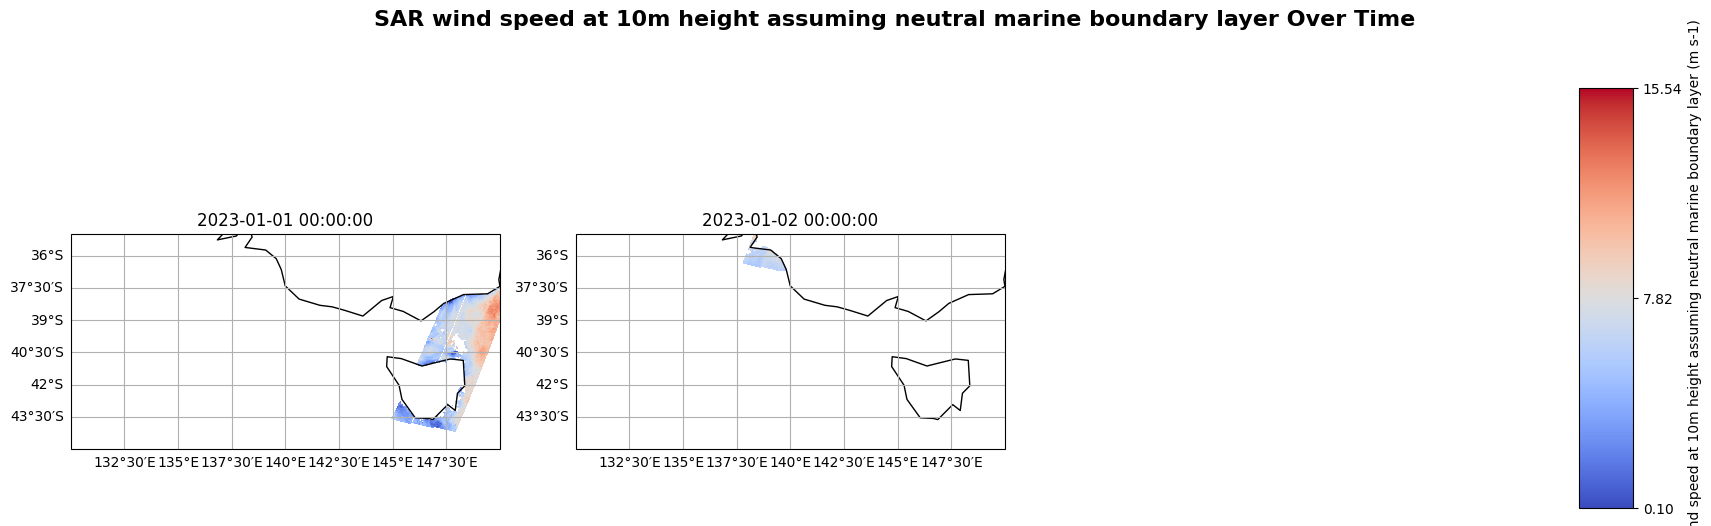

CPU times: user 12.1 s, sys: 6.44 s, total: 18.6 s
Wall time: 17.9 s


In [10]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='WSPD', 
                                                    date_start='2023-01-01',                                                
                                                    lon_name_override="LONGITUDE", 
                                                    lat_name_override="LATITUDE", 
                                                    lon_slice=(130, 150), 
                                                    lat_slice=(-45, -35), 
                                                    n_days=2, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False)

2026-05-26 15:30:26,824 - aodn.GetAodn - INFO - Plotting 'SAR wind from direction at 10m height, measured positive clockwise from due North' for 2 time steps.
/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:3754: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


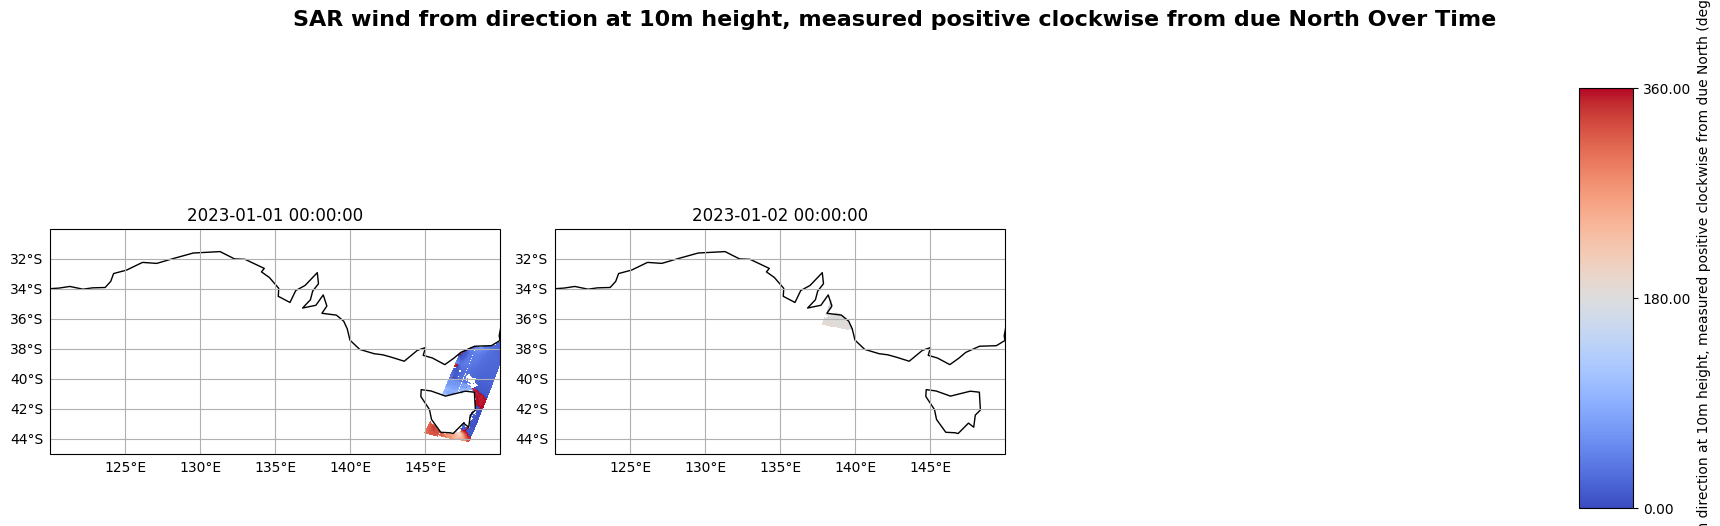

CPU times: user 12.9 s, sys: 8.42 s, total: 21.3 s
Wall time: 20.8 s


In [11]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='WDIR', 
                                                    date_start='2023-01-01',                                                
                                                    lon_name_override="LONGITUDE", 
                                                    lat_name_override="LATITUDE", 
                                                    lon_slice=(120, 150), 
                                                    lat_slice=(-45, -30), 
                                                    n_days=2, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False)

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:3982: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


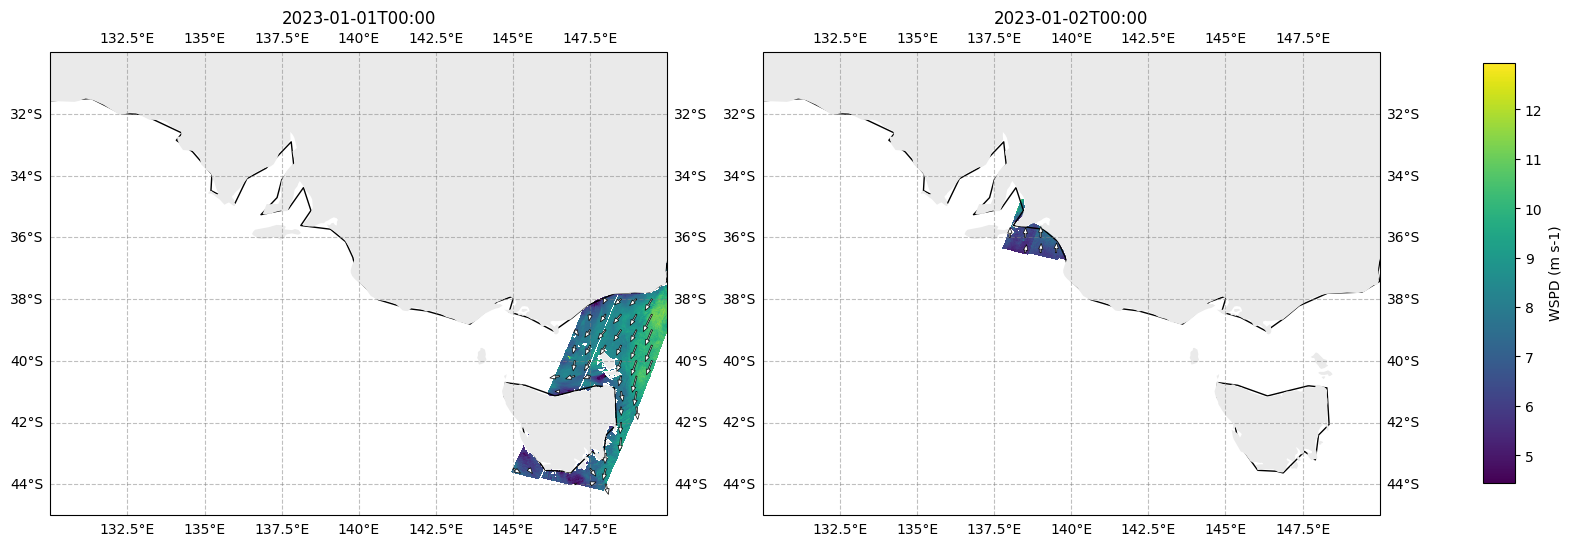

CPU times: user 8.96 s, sys: 4.82 s, total: 13.8 s
Wall time: 13.7 s


In [12]:
%%time
time_series_df = aodn_dataset.plot_gridded_vector_field(speed_var_name='WSPD',
                                                    dir_var_name='WDIR',
                                                    date_start='2023-01-01',                                                
                                                    lon_name_override="LONGITUDE", 
                                                    lat_name_override="LATITUDE", 
                                                    lon_slice=(130, 150), 
                                                    lat_slice=(-45, -30), 
                                                    n_days=2, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False, 
                                                    skip_step=50)